# LLM screening on benchset set A — diagnostic notebook

**What this is.** The screening pilot (`reports/wf_llm_pilot_findings.md`) ran on TIRI's six
use cases at 26–77% positive and said so in its own scope note: at that prevalence the
all-positive baseline scores F2 = 0.872 and the metric cannot separate the ensemble (+0.021)
from the best LLM (+0.013). `CONTEXT.md` §4 makes the same point twice — those pools are "a
poor surface for judging a recall-oriented system", and "model ranking is not stable across
prevalence regimes."

`benchset_v1_large_set_a` is the surface that fixes it: **8 collections, 62,229 papers, 1,362
relevant (2.19%)**. The all-positive floor drops to **0.101**, so F2 discriminates here.

**Three things to hold onto while reading:**

1. **Everything is at population prevalence.** Scoring all 62,229 rows × 4 models is ~$130
   and almost all of it buys negatives, so the run scores every positive plus a random share
   of negatives and reweights (`scripts/benchset_metrics.py`). Recall and ROC-AUC survive
   sampling untouched; precision, F2, WSS@95 and recall@k need the weight, and forgetting it
   gives a flatteringly wrong answer. `reports/wf_llm_benchset_a_baselines.md` is the gate
   that proves the sample reproduces the corpus before any money was spent.
2. **The bar is the cold-start cosine ranker**, already on disk in set A's feature columns.
   Set A has no shipped ensemble, and `wf_llm_pilot_findings.md` §8 identified the cold-start
   contest as the more winnable one and the one that would replace something real.
3. **`brouwer_2019` is 60% of set A and trivially easy** (AUC 0.99, 62 positives in 37,401
   rows). Any pooled number is mostly that collection. Per-collection results and win counts
   are the honest read — `CONTEXT.md` §5's rule, and it bites hard here.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

SCRIPTS_DIR = Path("../../scripts").resolve()
sys.path.insert(0, str(SCRIPTS_DIR))

from analyze_benchset_a import BASELINE, baseline_table, load_all, per_use_case
from benchset_metrics import all_positive_f2, recall_at, weighted_prf

REPORTS = Path("../../reports").resolve()
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

resp, man = load_all()
base = baseline_table(man).set_index("use_case")
print(f"{len(resp):,} scored responses across "
      f"{resp.groupby(['model', 'variant', 'arm']).ngroups} cells")
print(resp.groupby(["arm", "variant"]).model.nunique().to_string())

89,937 scored responses across 9 cells
arm          variant
B0 raw       P2         1
B1 supplied  P1         2
             P2         4
B2 induced   P2         1
B✗ shuffled  P2         1


## 1. The surface — why F2 means something here and did not before

F2 weights recall 5:1, so at high prevalence "mark everything relevant" already scores well:
precision = prevalence, recall = 1, F2 = 5p/(4p+1). That is the floor every F2 in this
notebook sits on. On TIRI's pooled 57.7% it is **0.872** and swamps the signal; here the
pooled floor is **0.101**.

The chart below is the whole argument for running on set A, and also the warning about
`leenaars_2020`, `muthu_2021`, `van_der_valk_2021` and `nelson_2002` — at 8.6–22.4% positive
their individual floors are still 0.32–0.59, so a good-looking F2 there is mostly prevalence.

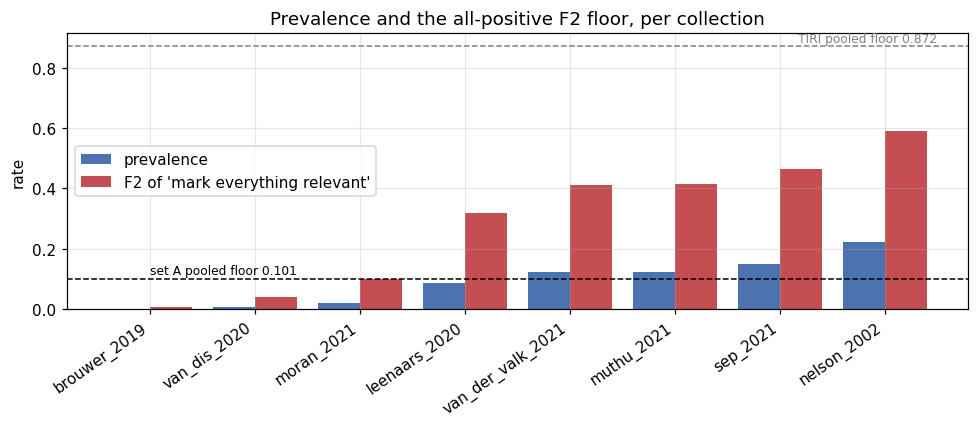

,prevalence,n_population,n_positive,floor_f2
brouwer_2019,0.002,37401.0,62.0,0.008
van_dis_2020,0.008,8938.0,72.0,0.039
moran_2021,0.022,5154.0,111.0,0.099
leenaars_2020,0.086,6711.0,576.0,0.319
van_der_valk_2021,0.123,710.0,87.0,0.411
muthu_2021,0.124,2687.0,334.0,0.415
sep_2021,0.148,270.0,40.0,0.465
nelson_2002,0.223,358.0,80.0,0.590


In [2]:
prev = man.groupby("use_case_key").apply(
    lambda g: pd.Series({
        "prevalence": g.w[g.y == 1].sum() / g.w.sum(),
        "n_population": g.w.sum(),
        "n_positive": int(g.y.sum()),
        "floor_f2": all_positive_f2(g.y.to_numpy(), g.w.to_numpy()),
    }), include_groups=False)
prev.index = [i.replace("synergy_", "") for i in prev.index]
prev = prev.sort_values("prevalence")

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(prev))
ax.bar(x - 0.2, prev.prevalence, 0.4, label="prevalence", color="#4C72B0")
ax.bar(x + 0.2, prev.floor_f2, 0.4, label="F2 of 'mark everything relevant'", color="#C44E52")
ax.axhline(0.872, ls="--", c="grey", lw=1)
ax.text(len(prev) - 0.5, 0.885, "TIRI pooled floor 0.872", ha="right", fontsize=8, color="grey")
ax.axhline(0.101, ls="--", c="black", lw=1)
ax.text(0, 0.115, "set A pooled floor 0.101", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(prev.index, rotation=35, ha="right")
ax.set_ylabel("rate"); ax.legend(); ax.set_title("Prevalence and the all-positive F2 floor, per collection")
plt.tight_layout(); plt.show()
display(prev.round(3))

## 2. Ranking — can the LLM out-rank a cosine-to-brief?

`cos_brief_qwen4b` needs no labels, no fitting and no LLM call: it is the cold-start rung
already shipped. Bars below the line lose to it.

Watch `moran_2021`. Every embedding and the lexical block score it **below chance** (0.43–0.45),
so its supplied brief actively points away from its labels. It is the one collection where a
model that reads the abstract could beat a ranker outright — and the one that could instead
expose a corpus defect.

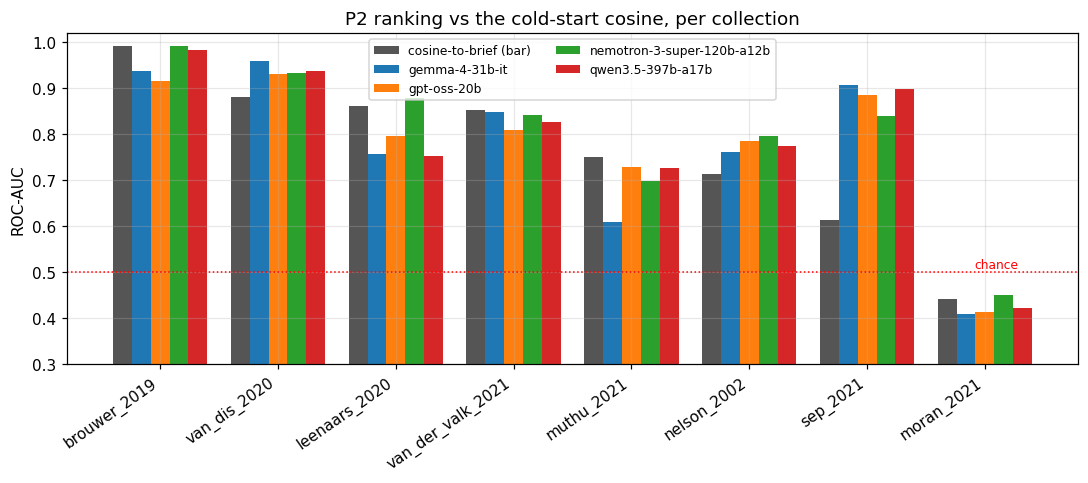

model,cosine (bar),gemma-4-31b-it,gpt-oss-20b,nemotron-3-super-120b-a12b,qwen3.5-397b-a17b
use_case,,,,,
brouwer_2019,0.993,0.938,0.916,0.992,0.984
van_dis_2020,0.881,0.959,0.931,0.933,0.938
leenaars_2020,0.862,0.758,0.797,0.878,0.753
van_der_valk_2021,0.853,0.848,0.808,0.841,0.828
muthu_2021,0.750,0.610,0.729,0.698,0.727
nelson_2002,0.714,0.761,0.786,0.797,0.774
sep_2021,0.613,0.907,0.886,0.840,0.899
moran_2021,0.441,0.408,0.413,0.451,0.422


In [3]:
puc = per_use_case(resp[resp.arm == "B1 supplied"])
p2 = puc[puc.variant == "P2"]
piv = p2.pivot_table(index="use_case", columns="model", values="auc")
piv.insert(0, "cosine (bar)", base.auc)
order = base.sort_values("auc", ascending=False).index
piv = piv.reindex(order)

fig, ax = plt.subplots(figsize=(10, 4.5))
models = [c for c in piv.columns if c != "cosine (bar)"]
x = np.arange(len(piv)); width = 0.8 / (len(models) + 1)
ax.bar(x, piv["cosine (bar)"], width, label="cosine-to-brief (bar)", color="#555555")
for i, m in enumerate(models, 1):
    ax.bar(x + i * width, piv[m], width, label=m)
ax.axhline(0.5, ls=":", c="red", lw=1)
ax.text(len(piv) - 0.4, 0.51, "chance", ha="right", fontsize=8, color="red")
ax.set_xticks(x + 0.4 - width / 2); ax.set_xticklabels(piv.index, rotation=35, ha="right")
ax.set_ylabel("ROC-AUC"); ax.set_ylim(0.3, 1.02)
ax.legend(fontsize=8, ncol=2); ax.set_title("P2 ranking vs the cold-start cosine, per collection")
plt.tight_layout(); plt.show()
display(piv.round(3))

In [4]:
FLOOR = 0.03  # CONTEXT.md §5 — gaps under this are not established
wins = pd.DataFrame({
    "beats_cosine": {m: int((piv[m] > piv["cosine (bar)"] + FLOOR).sum()) for m in models},
    "loses_to_cosine": {m: int((piv[m] < piv["cosine (bar)"] - FLOOR).sum()) for m in models},
    "mean_auc": {m: piv[m].mean() for m in models},
})
wins.loc["cosine baseline", ["mean_auc"]] = base.auc.mean()
display(wins.round(3))
print("Mean-AUC is dominated by brouwer_2019 (60% of set A). Win counts are the honest read.")

,beats_cosine,loses_to_cosine,mean_auc
gemma-4-31b-it,3.0,4.0,0.774
gpt-oss-20b,3.0,3.0,0.783
nemotron-3-super-120b-a12b,3.0,1.0,0.804
qwen3.5-397b-a17b,3.0,1.0,0.790
cosine baseline,NaN,NaN,0.763


Mean-AUC is dominated by brouwer_2019 (60% of set A). Win counts are the honest read.


## 3. The operating point — F2 at 2.19% prevalence, against the floor

`f2_own` is the model's own verdict with nothing tuned. This is the number a reviewer would
actually get, and unlike the cosine it exists at all — a ranker orders papers but cannot
decide where to stop.

The dashed line per collection is its all-positive floor. A bar under the line means the
model is worse than marking everything relevant.

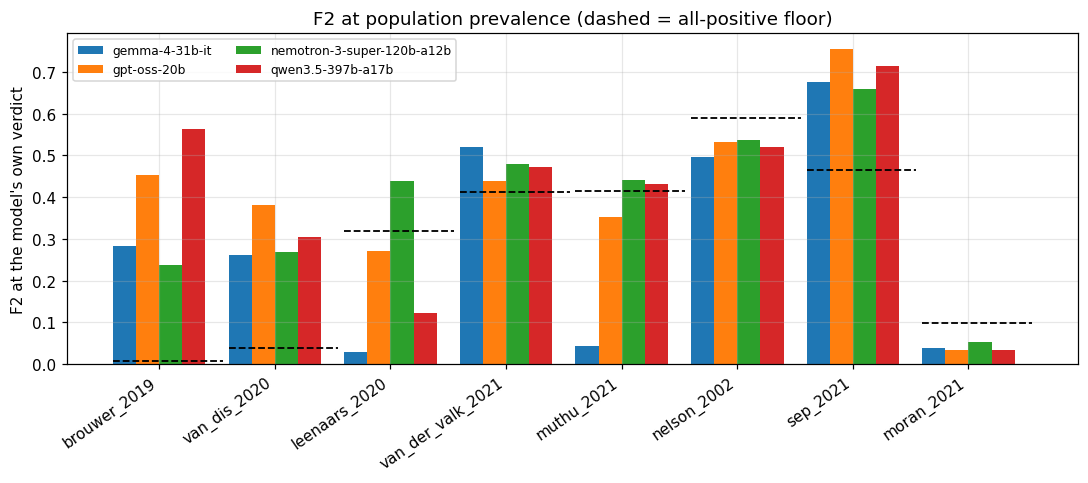

model,gemma-4-31b-it,gpt-oss-20b,nemotron-3-super-120b-a12b,qwen3.5-397b-a17b,floor
use_case,,,,,
brouwer_2019,0.282,0.452,0.238,0.564,0.008
van_dis_2020,0.261,0.382,0.268,0.303,0.039
leenaars_2020,0.030,0.271,0.437,0.122,0.319
van_der_valk_2021,0.520,0.437,0.479,0.471,0.411
muthu_2021,0.044,0.351,0.441,0.432,0.415
nelson_2002,0.496,0.532,0.536,0.520,0.590
sep_2021,0.675,0.755,0.659,0.714,0.465
moran_2021,0.038,0.033,0.052,0.033,0.099


In [5]:
f2 = p2.pivot_table(index="use_case", columns="model", values="f2_own").reindex(order)
floors = prev.reindex(order).floor_f2

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(f2)); width = 0.8 / len(f2.columns)
for i, m in enumerate(f2.columns):
    ax.bar(x + i * width, f2[m], width, label=m)
for i, (uc, fl) in enumerate(floors.items()):
    ax.plot([i - 0.1, i + 0.85], [fl, fl], c="black", ls="--", lw=1.2)
ax.set_xticks(x + 0.4 - width / 2); ax.set_xticklabels(f2.index, rotation=35, ha="right")
ax.set_ylabel("F2 at the model's own verdict")
ax.set_title("F2 at population prevalence (dashed = all-positive floor)")
ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()
display(f2.assign(floor=floors).round(3))

## 4. Does "when uncertain, include" survive the prevalence drop?

The pilot's most transferable finding was that adding one sentence — *a missed relevant paper
is about five times as costly as a false positive; when uncertain, include* — moved F2@own by
**+0.31 to +0.37** without any labelled data to tune against.

That was measured at 26–77% prevalence, where including a doubtful paper is nearly free. At
2.19% each marginal inclusion costs roughly **45 false positives per true one**. This is the
same instruction, re-priced. The chart plots what a reviewer buys: recall gained against
corpus read.

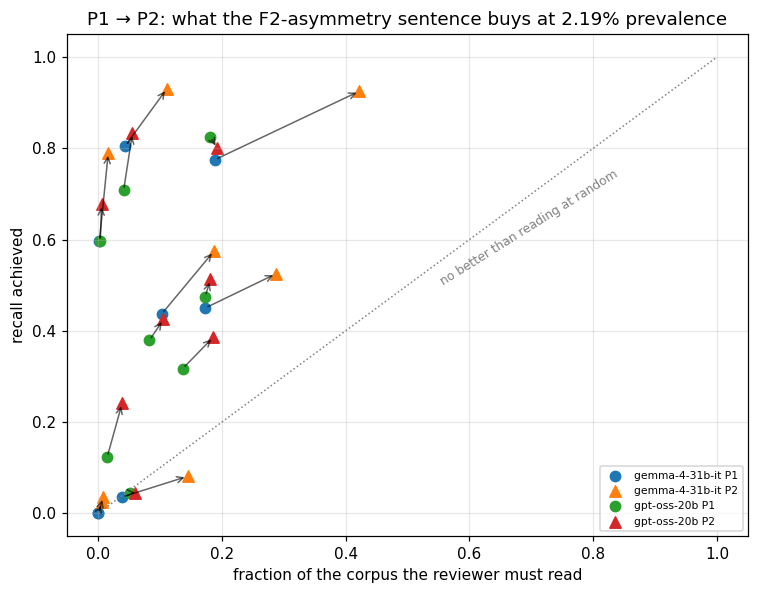

recall  screened  precision  f2_own    auc
model          variant                                            
gemma-4-31b-it P1        0.388     0.069      0.288   0.333  0.759
               P2        0.486     0.148      0.261   0.293  0.774
gpt-oss-20b    P1        0.434     0.086      0.409   0.382  0.772
               P2        0.490     0.103      0.357   0.402  0.783

In [6]:
both = puc[puc.model.isin(puc[puc.variant == "P1"].model.unique())]
fig, ax = plt.subplots(figsize=(7, 5.5))
for m, g in both.groupby("model"):
    for uc, gg in g.groupby("use_case"):
        p1 = gg[gg.variant == "P1"]; p2r = gg[gg.variant == "P2"]
        if p1.empty or p2r.empty:
            continue
        ax.annotate("", xy=(p2r.screened_own.iloc[0], p2r.recall_own.iloc[0]),
                    xytext=(p1.screened_own.iloc[0], p1.recall_own.iloc[0]),
                    arrowprops=dict(arrowstyle="->", lw=1, alpha=0.6))
    ax.scatter(g[g.variant == "P1"].screened_own, g[g.variant == "P1"].recall_own,
               marker="o", s=45, label=f"{m} P1")
    ax.scatter(g[g.variant == "P2"].screened_own, g[g.variant == "P2"].recall_own,
               marker="^", s=55, label=f"{m} P2")
lims = np.linspace(0, 1, 50)
ax.plot(lims, lims, ls=":", c="grey", lw=1)
ax.text(0.55, 0.5, "no better than reading at random", rotation=32, fontsize=8, color="grey")
ax.set_xlabel("fraction of the corpus the reviewer must read")
ax.set_ylabel("recall achieved")
ax.set_title("P1 → P2: what the F2-asymmetry sentence buys at 2.19% prevalence")
ax.legend(fontsize=7); plt.tight_layout(); plt.show()

agg = both.groupby(["model", "variant"]).agg(
    recall=("recall_own", "mean"), screened=("screened_own", "mean"),
    precision=("precision_own", "mean"), f2_own=("f2_own", "mean"), auc=("auc", "mean"))
display(agg.round(3))

## 5. The brief-format ladder — is the brief the bottleneck?

Same prompt (P2), four brief sets, **scored on test + validate only** because B2 was induced
from train labels and every arm must sit on identical unseen rows.

| arm | brief |
|---|---|
| **B0 raw** | the review's own title and abstract, LLM-written term lists stripped |
| **B1 supplied** | the shipped brief |
| **B2 induced** | a rule set induced from *train-fold labels only* (`scripts/induce_rule_set.py`) |
| **B✗ shuffled** | another collection's brief — the falsification control |

B0 vs B1 is the open question `CONTEXT.md` §4 flags and nobody has quantified: the
shuffled-brief control *failed* on old SYNERGY, whose briefs were "a description of what a
review did ... and carry no curated term lists". This export has term lists — written by an
LLM from the same abstract, blind to labels. B0 strips them back off.

auc  f2_own  recall  screened  wss95
model                      arm                                                
gemma-4-31b-it             B0 raw       0.777   0.349   0.559     0.147  0.250
                           B1 supplied  0.777   0.285   0.484     0.148  0.331
                           B2 induced   0.834   0.488   0.674     0.169  0.338
                           B✗ shuffled  0.498   0.000   0.000     0.000 -0.016
gpt-oss-20b                B1 supplied  0.802   0.400   0.510     0.099  0.254
nemotron-3-super-120b-a12b B1 supplied  0.815   0.404   0.574     0.117  0.312
qwen3.5-397b-a17b          B1 supplied  0.793   0.398   0.508     0.124  0.334

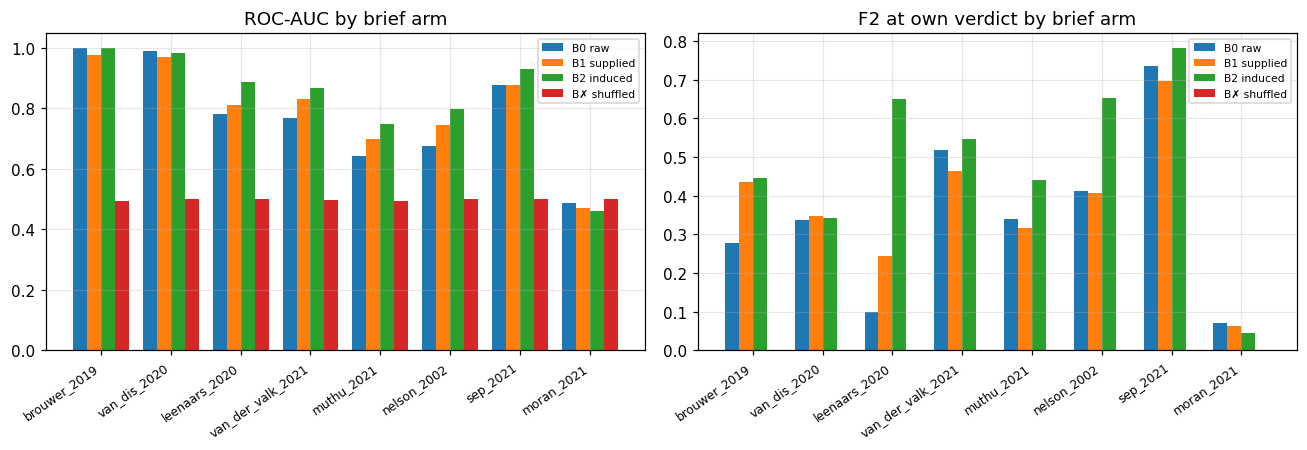

In [7]:
held = resp[(resp.split != "train") & (resp.variant == "P2")]
lp = per_use_case(held)
lad = lp.groupby(["model", "arm"]).agg(
    auc=("auc", "mean"), f2_own=("f2_own", "mean"), recall=("recall_own", "mean"),
    screened=("screened_own", "mean"), wss95=("wss95", "mean"))
display(lad.round(3))

arms = [a for a in ["B0 raw", "B1 supplied", "B2 induced", "B✗ shuffled"]
        if a in lp.arm.unique()]
if len(arms) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    for ax, metric, title in zip(axes, ["auc", "f2_own"],
                                 ["ROC-AUC", "F2 at own verdict"]):
        sub = lp[lp.arm.isin(arms)].pivot_table(index="use_case", columns="arm", values=metric)
        sub = sub.reindex(order)[arms]
        x = np.arange(len(sub)); width = 0.8 / len(arms)
        for i, a in enumerate(arms):
            ax.bar(x + i * width, sub[a], width, label=a)
        ax.set_xticks(x + 0.4 - width / 2)
        ax.set_xticklabels(sub.index, rotation=35, ha="right", fontsize=8)
        ax.set_title(f"{title} by brief arm"); ax.legend(fontsize=7)
    plt.tight_layout(); plt.show()

### The falsification check gates everything above

Every collection's papers re-scored against a **different** collection's brief. If the models
still rank well on someone else's criteria they are scoring "is this a good paper", not "does
this match this brief", and every number in this notebook is measuring the wrong thing.

This is the repo's signature control (`CONTEXT.md` §7: *"the shuffled-brief control is the
pattern to copy"*), and it is not a formality — it passes decisively on TIRI and **failed** on
old SYNERGY.

In [8]:
sh = lp[lp.arm == "B✗ shuffled"]
if sh.empty:
    print("shuffled-brief control not run yet")
else:
    real = lp[lp.arm == "B1 supplied"].set_index(["model", "use_case"])
    ctl = sh.set_index(["model", "use_case"])
    cmp = pd.DataFrame({"auc_real": real.auc, "auc_shuffled": ctl.auc,
                        "f2own_real": real.f2_own, "f2own_shuffled": ctl.f2_own,
                        "screened_real": real.screened_own,
                        "screened_shuffled": ctl.screened_own}).dropna()
    display(cmp.round(3))
    print(f"mean AUC {cmp.auc_real.mean():.3f} -> {cmp.auc_shuffled.mean():.3f} "
          f"| mean predicted-positive rate {cmp.screened_real.mean():.3f} -> "
          f"{cmp.screened_shuffled.mean():.3f} | degraded on "
          f"{int((cmp.auc_shuffled < cmp.auc_real).sum())}/{len(cmp)} cells")

auc_real  auc_shuffled  f2own_real  \
model          use_case                                                
gemma-4-31b-it brouwer_2019          0.970         0.494       0.343   
               leenaars_2020         0.766         0.500       0.053   
               moran_2021            0.453         0.500       0.059   
               muthu_2021            0.604         0.495       0.028   
               nelson_2002           0.705         0.500       0.364   
               sep_2021              0.884         0.500       0.636   
               van_der_valk_2021     0.853         0.498       0.510   
               van_dis_2020          0.982         0.500       0.288   

                                  f2own_shuffled  screened_real  \
model          use_case                                           
gemma-4-31b-it brouwer_2019                  0.0          0.015   
               leenaars_2020                 0.0          0.010   
               moran_2021                    0.0          0.163   
               muthu_2021                    0.0          0.007   
               nelson_2002                   0.0          0.259   
               sep_2021                      0.0          0.426   
               van_der_valk_2021             0.0          0.197   
               van_dis_2020                  0.0          0.104   

                                  screened_shuffled  
model          use_case                              
gemma-4-31b-it brouwer_2019                     0.0  
               leenaars_2020                    0.0  
               moran_2021                       0.0  
               muthu_2021                       0.0  
               nelson_2002                      0.0  
               sep_2021                         0.0  
               van_der_valk_2021                0.0  
               van_dis_2020                     0.0

mean AUC 0.777 -> 0.498 | mean predicted-positive rate 0.148 -> 0.000 | degraded on 7/8 cells


## 6. What a reviewer actually buys — recall against work

WSS@95 is the standard citation-screening metric, but it is fragile for an LLM: verbalised
0–100 scores are extremely lumpy (the pilot measured a tie fraction above 0.99), so the 95%
cutoff lands inside a tie block thousands of rows wide and the answer depends on sort order.
`benchset_metrics.wss_at` resolves ties by expectation and reports `tie_frac` alongside, but
the honest comparison at a single operating point is simply **(recall, fraction read)** — which
is what this chart shows, with the cosine's full ranking curve behind it.

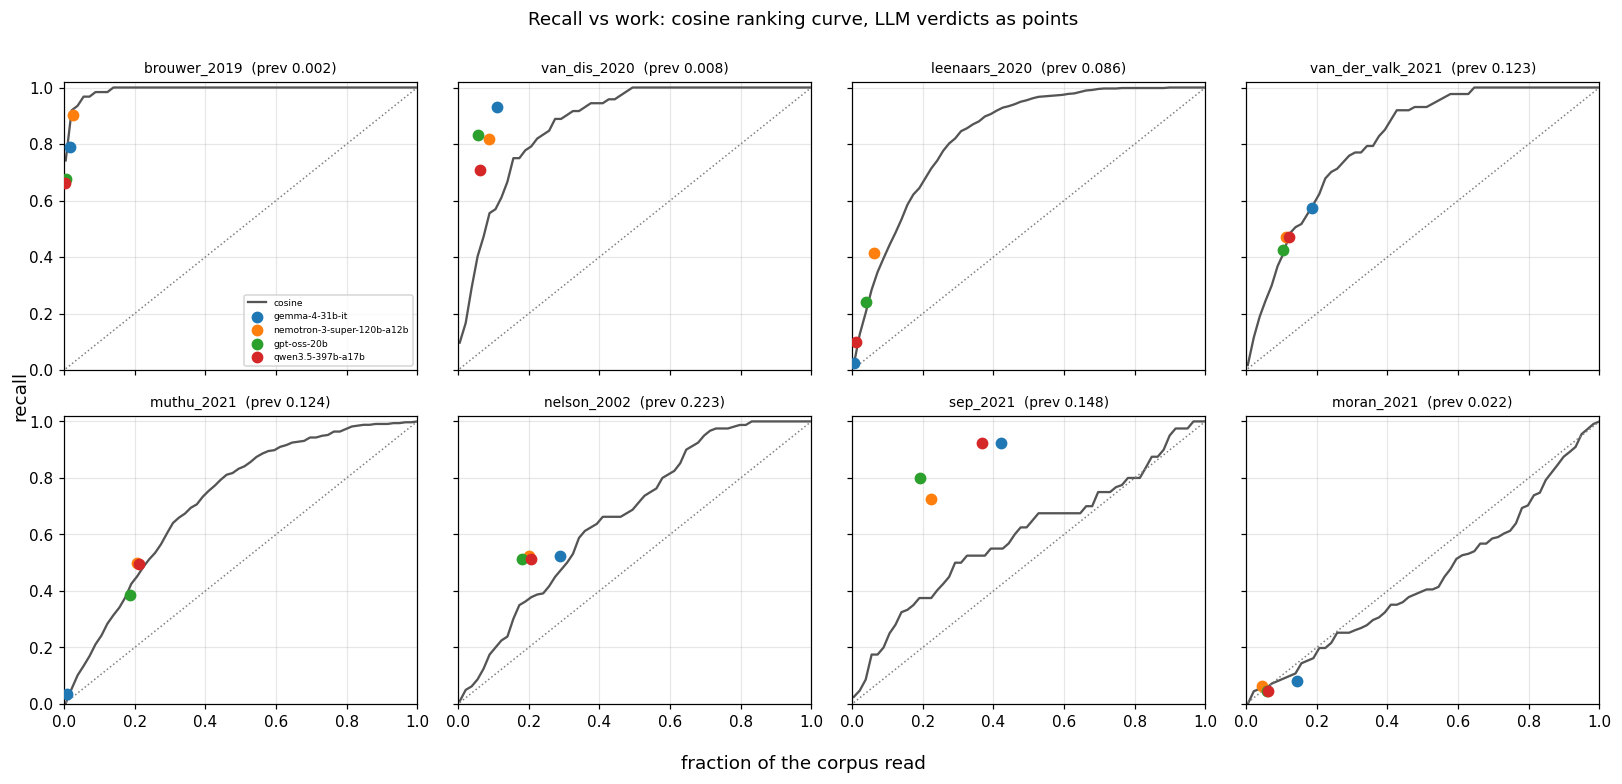

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7), sharex=True, sharey=True)
for ax, uc in zip(axes.ravel(), order):
    key = "synergy_" + uc
    g = man[man.use_case_key == key]
    y, w, s = g.y.to_numpy(), g.w.to_numpy(), g[BASELINE].to_numpy()
    fr = np.linspace(0.005, 1.0, 60)
    ax.plot(fr, [recall_at(y, s, w, f) for f in fr], c="#555555", lw=1.5, label="cosine")
    ax.plot(fr, fr, ls=":", c="grey", lw=1)
    sub = p2[p2.use_case == uc]
    for _, r in sub.iterrows():
        ax.scatter(r.screened_own, r.recall_own, s=45, label=r.model, zorder=3)
    ax.set_title(f"{uc}  (prev {prev.loc[uc, 'prevalence']:.3f})", fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
axes[0, 0].legend(fontsize=6)
fig.supxlabel("fraction of the corpus read"); fig.supylabel("recall")
fig.suptitle("Recall vs work: cosine ranking curve, LLM verdicts as points", y=1.0)
plt.tight_layout(); plt.show()

## 7. Engineering findings — provider choice is part of the measurement

The pilot already found that provider choice moved measured "model compliance" from 68% to
100% with model, prompt and parameters identical. Set A pushed harder on the same seam,
because 62,229 rows exposes throughput limits that 1,848 rows never touches.

In [10]:
summ = []
for p in sorted(REPORTS.glob("wf_llm_setA_*_summary.csv")):
    d = pd.read_csv(p); d["source"] = p.stem.replace("_summary", "")
    summ.append(d)
if summ:
    s = pd.concat(summ, ignore_index=True)
    display(s[["model", "variant", "source", "n", "parse_rate", "score_rate", "http_errors",
               "truncated", "param_drops", "median_latency_s", "median_prompt_tok",
               "cost_usd", "providers"]].round(3))
    print(f"total cell cost across set A: ${s.cost_usd.sum():.2f}")

,model,variant,source,n,parse_rate,score_rate,http_errors,truncated,param_drops,median_latency_s,median_prompt_tok,cost_usd,providers
0,google/gemma-4-31b-it,P2,wf_llm_setA_control_P2_gemma,9993,1.0,1.0,0,0,0,0.48,999.0,1.508,Friendli
1,google/gemma-4-31b-it,P1,wf_llm_setA_grid_P1-P2_gemma,9993,1.0,1.0,0,0,0,0.45,931.0,1.419,Friendli
2,google/gemma-4-31b-it,P2,wf_llm_setA_grid_P1-P2_gemma,9993,1.0,1.0,0,0,0,0.46,993.0,1.505,Friendli
3,openai/gpt-oss-20b,P1,wf_llm_setA_grid_P1-P2_gptoss,9993,1.0,1.0,0,2,0,1.25,974.0,0.409,CoreWeave
4,openai/gpt-oss-20b,P2,wf_llm_setA_grid_P1-P2_gptoss,9993,1.0,1.0,0,1,0,1.10,1034.0,0.418,CoreWeave
5,google/gemma-4-31b-it,P2,wf_llm_setA_grid_P2_induced_gemma,9993,1.0,1.0,0,0,0,0.46,967.0,1.467,Friendli
6,nvidia/nemotron-3-super-120b-a12b,P2,wf_llm_setA_grid_P2_nemotron,9993,1.0,1.0,0,4,9993,0.95,1009.0,3.400,Nebius
7,qwen/qwen3.5-397b-a17b,P2,wf_llm_setA_grid_P2_qwen,9993,1.0,1.0,0,0,0,1.17,1018.0,4.638,Alibaba
8,google/gemma-4-31b-it,P2,wf_llm_setA_grid_P2_raw_gemma,9993,1.0,1.0,0,0,0,0.46,873.0,1.337,Friendli
9,openai/gpt-oss-20b,P2,wf_llm_setA_smoke,240,1.0,1.0,0,0,0,2.56,1048.5,0.011,CoreWeave


total cell cost across set A: $16.11


## 8. Read this before quoting any number above

- **Briefs sit closer to the answer than a real protocol.** They were written from each
  review's abstract — i.e. from a summary of the papers that were included. This inflates
  absolute scores for *every* brief-reading method equally, the cosine baseline included.
  The dataset's own framing applies: fine for comparing methods against each other, not proof
  of what a system would do on a fresh question. B2 goes further and sees train labels
  directly, which is why it is reported only on unseen rows and against a zero-shot baseline.
- **All SYNERGY.** Set A is 8 SYNERGY collections and nothing else. `CONTEXT.md` §4's warning
  that model ranking is unstable across prevalence regimes cuts both ways — these results
  transfer to TIRI's own use cases no better than the pilot's transferred here.
- **`brouwer_2019` dominates every pooled number** and is easy. Win counts, not means.
- **`moran_2021` may be a corpus defect** rather than a hard problem. A ranker scoring below
  chance on 5,154 papers is not a difficulty signal, it is a sign the brief and the labels
  disagree. Treat any large win there as a hypothesis about the brief, not about the model.
- **Nothing here is a determinism result.** Stage C (repeat runs at temperature 0, flip rate)
  has still not been run, and `nemotron-3-super` cannot honour `seed` on any endpoint that
  serves it.